# 1. Setup & Configuration

In [2]:
import pandas as pd
import os

# Configuration
DATA_DIR = '/Users/chen/Desktop/Nus/Class/Practice Module/Project/fashion-recommender/data/raw'
OUTPUT_DIR = '/Users/chen/Desktop/Nus/Class/Practice Module/Project/fashion-recommender/data/processed/kg'

print("Setup complete. Ready to build the graph")


Setup complete. Ready to build the graph


# 2. Static Attribute Extraction

Handles Top/Bottom Filtering, Gender/Category and Weather/Occasion attributes


In [3]:
# Load attributes
print("Loading article attributes...")
articles = pd.read_csv(os.path.join(DATA_DIR, 'articles.csv'))

# Fill missing descriptopns
articles['detail_desc'] = articles['detail_desc'].fillna('').str.lower()
articles['product_type_name'] = articles['product_type_name'].str.lower()
articles['index_name'] = articles['index_group_name'].str.lower()

Loading article attributes...


In [4]:
# Filter Tops and Bottom
is_top = (articles['product_group_name'] == 'Garment Upper body') & ((articles['index_group_name'] == 'Ladieswear') | (articles['index_group_name'] == 'Menswear'))
is_bottom = (articles['product_group_name'] == 'Garment Lower body') & ((articles['index_group_name'] == 'Ladieswear') | (articles['index_group_name'] == 'Menswear'))

# Create specific DataFrames
tops_df = articles[is_top].copy()
bottoms_df = articles[is_bottom].copy()
tops_df['entity_type'] = 'Top'
bottoms_df['entity_type'] = 'Bottom'

# Combine relevant items
relevant_items = pd.concat([tops_df, bottoms_df], ignore_index=True)
print(f"Filtered {len(tops_df)} tops and {len(bottoms_df)} bottoms, total {len(relevant_items)} relevant items.")

tops_df['article_id'] = tops_df['article_id'].apply(lambda x: f"{int(x):010d}")
bottoms_df['article_id'] = bottoms_df['article_id'].apply(lambda x: f"{int(x):010d}")

valid_top_ids = set(tops_df['article_id'])
valid_bottom_ids = set(bottoms_df['article_id'])

print(f"Valid Top IDs: {len(valid_top_ids)}, Valid Bottom IDs: {len(valid_bottom_ids)}")
print("Sample Top IDs:", list(valid_top_ids)[:5])

Filtered 20965 tops and 8206 bottoms, total 29171 relevant items.
Valid Top IDs: 20965, Valid Bottom IDs: 8206
Sample Top IDs: ['0765535003', '0727808003', '0621735009', '0875784002', '0694064003']


# 3. Generate Gender Category

In [5]:
# Generate 'has_category' edges
category_edges = relevant_items[['article_id', 'index_group_name']].copy()
category_edges.columns = ['source', 'target']
category_edges['relation'] = 'has_category'

category_edges['source'] = category_edges['source'].apply(lambda x: f"{int(x):010d}")

# 4. Generate Weather & Occasion Attributes

In [6]:
def get_weather(row):
    " Determine weather nased on keywords"
    desc = str(row['detail_desc']).lower()
    prod_type = str(row['product_type_name']).lower()
    
    # Cold / Winter
    if any(x in desc for x in ['wool', 'fleece', 'knit', 'thermal', 'padded', 'warm']) or \
        prod_type in ['coat', 'jacket', 'sweater', 'hoodie', 'cardigan']:
        return 'Cold'

    # Hot / Summer
    if any(x in desc for x in ['linen', 'sleeveless', 'straps', 'short sleeve', 'coolmax']) or \
        prod_type in ['t-shirt', 'tank top', 'shorts', 'skirt', 'dress', 'bikini', 'swimsuit', 'swinwear']:
        return 'Hot'
    
    # Default if no strong signal
    return 'Mild'

def get_occasion(row):
    " Determine occasion based on keywords"
    desc = str(row['detail_desc']).lower()
    prod_type = str(row['product_type_name']).lower()
    section = str(row['section_name']).lower()

    # Sport / Activewear
    if 'sport' in section or prod_type in ['leggings', 'sports bra', 'running shorts', 'activewear']:
        return 'Sport'
    
    # Formal / Offixw
    if prod_type in ['blazer', 'suit', 'trousers', 'shirt', 'blouse'] or \
        'silk' in desc or 'tailored' in desc:
        return 'Formal'

    # Party / Night Out
    if any(x in desc for x in ['sequin', 'lace', 'velvet', 'satin', 'metallic']) or \
        'party' in section:
        return 'Party'

    # Casual / Everyday
    return 'Casual'

print ("Infering weather and occasion attributes...")
relevant_items['weather'] = relevant_items.apply(get_weather, axis=1)
relevant_items['occasion'] = relevant_items.apply(get_occasion, axis=1)

# Create weather edges
weather_edges = relevant_items[['article_id', 'weather']].copy()
weather_edges.columns = ['source', 'target']
weather_edges['relation'] = 'suitable_for_weather'
weather_edges['source'] = weather_edges['source'].apply(lambda x: f"{int(x):010d}")

# Create occasion edges
occasion_edges = relevant_items[['article_id', 'occasion']].copy()
occasion_edges.columns = ['source', 'target']
occasion_edges['relation'] = 'suitable_for_occasion'
occasion_edges['source'] = occasion_edges['source'].apply(lambda x: f"{int(x):010d}")


print("Static attributes extracted and edges created.")
display(occasion_edges.head(3))

Infering weather and occasion attributes...
Static attributes extracted and edges created.


,source,target,relation
0,0108775015,Casual,suitable_for_occasion
1,0108775044,Casual,suitable_for_occasion
2,0108775051,Casual,suitable_for_occasion


# 5. Best Matches

In [12]:
# Generate 'best_matches_with' edges

# Get set of valid Ids to filter transactions
valid_top_ids = set(tops_df['article_id'])
valid_bottom_ids = set(bottoms_df['article_id'])

print(f"Valid top IDs: {len(valid_top_ids)}, Valid bottom IDs: {len(valid_bottom_ids)}")

print("Loading transactions (First 100k rows for testing)...")
trans = pd.read_csv(
    os.path.join(DATA_DIR, 'transactions_train.csv'),
    dtype={'article_id': str},
    usecols=['t_dat', 'customer_id', 'article_id'],
    nrows=100000
)

# Filter: Keep only transactions involving our relevant tops or Bottoms
trans = trans[trans['article_id'].isin(valid_top_ids | valid_bottom_ids)].copy()

print(f"Filtered transactions to {len(trans)} rows involving relevant tops and bottoms.")


# Tag them
trans['type'] = trans['article_id'].apply(
    lambda x: 'Top' if x in valid_top_ids else 'Bottom' if x in valid_bottom_ids else 'Unknown'
)

# Separate tops and bottoms transactions
trans_tops = trans[trans['type'] == 'Top']
trans_bottoms = trans[trans['type'] == 'Bottom']

print("Finding co-occurrences (Same customer, same date)...")

# Inner Join on customer_id and t_dat to find co-occurrences
merged = pd.merge(
    trans_tops[['customer_id', 't_dat', 'article_id']],
    trans_bottoms[['customer_id', 't_dat', 'article_id']],
    on=['customer_id', 't_dat'],
    suffixes=('_head', '_tail')
)

# Count frequency 
match_counts = merged.groupby(['article_id_head', 'article_id_tail']).size().reset_index(name='count')

#Find Best Matches
best_matches = match_counts.sort_values(['article_id_head','count'], ascending=[True,False])
best_matches = best_matches.groupby('article_id_head').head(10)

# Format for KG
match_edges = best_matches[['article_id_head', 'article_id_tail', 'count']].copy()
match_edges.columns = ['source', 'target', 'weight']
match_edges['relation'] = 'best_matches_with'

print(f"Found {len(match_edges)} best match edges.")
display(match_edges.head(3))


Valid top IDs: 20965, Valid bottom IDs: 8206
Loading transactions (First 100k rows for testing)...
Filtered transactions to 44224 rows involving relevant tops and bottoms.
Finding co-occurrences (Same customer, same date)...
Found 11146 best match edges.


,source,target,weight,relation
13,0108775015,0562245059,5,best_matches_with
20,0108775015,0652731008,4,best_matches_with
4,0108775015,0501396001,2,best_matches_with


# 6. Combine & Export

In [13]:
# Combine all edges
all_edge = pd.concat([
    category_edges,
    weather_edges,
    occasion_edges,
    match_edges
], ignore_index=True)

# Reorder columns
final_kg = all_edge[['source', 'relation', 'target', 'weight']]

print("Final Graph Statistics:")
print(f"Total edges: {len(final_kg)}")
print(final_kg['relation'].value_counts())

# Export
OUTPUT_PATH = os.path.join(OUTPUT_DIR, 'final_kg.csv')
final_kg.to_csv(OUTPUT_PATH, index=False)
print(f"Final KG saved to {OUTPUT_PATH}")

# Show sample of final KG
display(final_kg.sample(10))


Final Graph Statistics:
Total edges: 98659
relation
has_category             29171
suitable_for_weather     29171
suitable_for_occasion    29171
best_matches_with        11146
Name: count, dtype: int64
Final KG saved to /Users/chen/Desktop/Nus/Class/Practice Module/Project/fashion-recommender/data/processed/kg/final_kg.csv


,source,relation,target,weight
82574,0669429003,suitable_for_occasion,Formal,NaN
52991,0652635001,suitable_for_weather,Mild,NaN
75410,0816934005,suitable_for_occasion,Casual,NaN
4606,0592743050,has_category,Menswear,NaN
11404,0704029002,has_category,Ladieswear,NaN
85747,0816307001,suitable_for_occasion,Casual,NaN
1780,0534164033,has_category,Ladieswear,NaN
31188,0541272002,suitable_for_weather,Cold,NaN
98309,0694153002,best_matches_with,0568597006,1.0
81750,0631785002,suitable_for_occasion,Formal,NaN


# ------------------------------------

# Train the Embeddings

In [14]:
# Split kg into train/val/test
from pykeen.triples import TriplesFactory

# Convert DataFrame to PyKEEN TriplesFactory
tf = TriplesFactory.from_labeled_triples(
    triples=final_kg.values,
    create_inverse_triples=True
)

# Use the split method (80% train, 10% val, 10% test)
training, testing, validation = tf.split([0.8, 0.1, 0.1], random_state=42)

print(f"Training triples: {training.num_triples}")
print(f"Validation triples: {validation.num_triples}")
print(f"Testing triples: {testing.num_triples}")

# Check for leakage
print(f"Entities in Train: {training.num_entities}")
print(f"Entities in Validation: {testing.num_entities}")



Training triples: 78927
Validation triples: 9866
Testing triples: 9866
Entities in Train: 29179
Entities in Validation: 29179


In [15]:
from sklearn.model_selection import train_test_split
from pykeen.triples import TriplesFactory
from pykeen.pipeline import pipeline

# Separate the edges
metadata_edges = final_kg[final_kg['relation'].isin(['has_category', 'suitable_for_weather', 'suitable_for_occasion'])]
interaction_edges = final_kg[final_kg['relation'] == 'best_matches_with']

# Split ONLY the interaction edges
# 80% train, 20% Test
train_interactions, test_interactions = train_test_split(
    interaction_edges, 
    test_size=0.2, 
    random_state=42
)

# Combine to create final sets
# Training = All Metadata + 80% Interactions
train_set = pd.concat([metadata_edges, train_interactions], ignore_index=True)

# Test = 20% Interactions only
test_set = test_interactions

# Filter Test Set
# Remove any row from Test where items don't appear in Train
valid_train_entities = set(train_set['source']) | set(train_set['target'])

test_set = test_set[
    test_set['source'].isin(valid_train_entities) &
    test_set['target'].isin(valid_train_entities)
]

print(f"Final Train Set: {len(train_set)} edges")
print(f"Final Test Set: {len(test_set)} edges")

# Create Trainig Factory
traing_factory = TriplesFactory.from_labeled_triples(
    train_set[['source', 'relation', 'target']].values,
    create_inverse_triples=True
)

# Create Test Factory
test_factory = TriplesFactory.from_labeled_triples(
    test_set[['source', 'relation', 'target']].values,
    entity_to_id=traing_factory.entity_to_id,
    relation_to_id=traing_factory.relation_to_id,
    create_inverse_triples=True
)

Final Train Set: 96429 edges
Final Test Set: 2230 edges


In [16]:
from pykeen.pipeline import pipeline

# Train the Model 
result = pipeline(
    training=traing_factory,
    testing=test_factory,
    model='RotatE',
    epochs=400, 
    random_seed=42,
    model_kwargs=dict(embedding_dim=128),
    loss = 'Negative Sampling Self-Adversarial Loss',
    loss_kwargs=dict(
        margin=9.0,
        adversarial_temperature=1.0
        ),
    optimizer = 'Adam',
    optimizer_kwargs=dict(lr=0.001),
    negative_sampler = 'basic',
    negative_sampler_kwargs=dict(num_negs_per_pos=64),
    training_kwargs = dict(batch_size=1024),
)

# Get the entity embeddings
# entity_embeddings = result.model.entity_representations[0](indices=None)
# entity_to_id = result.training.entity_to_id

# Print the realistic tail metrics to check the score
df = result.metric_results.to_df()
simple_report = df[
    (df['Side'] == 'tail') &
    (df['Rank_type'] == 'realistic') &
    (df['Metric'].isin(['hits_at_5', 'hits_at_10']))
]

print(simple_report[['Metric', 'Value']])

No cuda devices were available. The model runs on CPU
INFO:pykeen.triples.triples_factory:Creating inverse triples.
/Users/chen/Desktop/Nus/Class/Practice Module/Project/fashion-recommender/.venv/lib/python3.14/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
Training epochs on cpu: 100%|██████████| 400/400 [5:47:22<00:00, 52.11s/epoch, loss=0.439, prev_loss=0.439]    
Evaluating on cpu:   0%|          | 0.00/2.23k [00:00<?, ?triple/s]WARNING:torch_max_mem.api:Encountered tensors on device_types={'cpu'} while only ['cuda'] are considered safe for automatic memory utilization maximization. This may lead to undocumented crashes (but can be safe, too).
Evaluating on cpu: 100%|██████████| 2.23k/2.23k [16:35<00:00, 2.24triple/s]  
INFO:pykeen.evaluation.evaluator:Evaluation took 21.18s seconds


         Metric     Value
193   hits_at_5  0.278924
202  hits_at_10  0.345740


In [16]:
# Evaluate the model
df = result.metric_results.to_df()

# Filter for the metric reults
simple_report = df[
    (df['Side'] == 'tail') &
    (df['Rank_type'] == 'realistic') &
    (df['Metric'].isin(['inverse_harmonic_mean_rank', 'hits_at_10', 'hits_at_5']))
]

print(simple_report[['Metric', 'Valuei']])


KeyError: "['Valuei'] not in index"

------------------------------------

In [11]:
import pandas as pd
import networkx as nx
from sklearn.model_selection import train_test_split
from pykeen.triples import TriplesFactory
from pykeen.pipeline import pipeline

# --- 1. SEPARATE EDGES ---
# Replace 'all_edges' with whatever your main dataframe is called
interaction_edges = final_kg[final_kg['relation'] == 'best_matches_with'].copy()
metadata_edges = final_kg[final_kg['relation'] != 'best_matches_with'].copy()

# --- 2. EXTRACT THE K-CORE ---
print("Building interaction graph...")
G = nx.from_pandas_edgelist(interaction_edges, 'source', 'target')
print(f"Original items (nodes): {G.number_of_nodes()}")
print(f"Original matches (edges): {G.number_of_edges()}")

# Keep only items that have at least 3 matches
k = 3
k_core_graph = nx.k_core(G, k=k)
valid_core_nodes = set(k_core_graph.nodes())

print(f"Items after {k}-Core filter: {len(valid_core_nodes)}")
print(f"Matches after {k}-Core filter: {k_core_graph.number_of_edges()}")

# --- 3. FILTER THE DATASETS ---
# Filter interactions: Both source and target must be in the dense core
clean_interactions = interaction_edges[
    (interaction_edges['source'].isin(valid_core_nodes)) & 
    (interaction_edges['target'].isin(valid_core_nodes))
]

# Filter metadata: Source (clothing item) must be in the dense core.
# Target (e.g., "Cold", "Casual") is kept regardless.
clean_metadata = metadata_edges[metadata_edges['source'].isin(valid_core_nodes)]

# --- 4. SAFE TRAIN/TEST SPLIT ---
# Split ONLY the interactions (80/20)
train_interact, test_interact = train_test_split(
    clean_interactions, test_size=0.2, random_state=42
)

# Combine metadata back into the training set
train_set = pd.concat([clean_metadata, train_interact])
test_set = test_interact

# CRITICAL: Ensure no test items are "orphans" missing from train
valid_train_entities = set(train_set['source']) | set(train_set['target'])
test_set = test_set[
    (test_set['source'].isin(valid_train_entities)) &
    (test_set['target'].isin(valid_train_entities))
]

print(f"Final Training Triples: {len(train_set)}")
print(f"Final Testing Triples: {len(test_set)}")

# --- 5. CREATE PYKEEN FACTORIES ---
# Training Factory
training_factory = TriplesFactory.from_labeled_triples(
    train_set[['source', 'relation', 'target']].values,
    create_inverse_triples=True, 
)

# Testing Factory (using Training Mappings!)
testing_factory = TriplesFactory.from_labeled_triples(
    test_set[['source', 'relation', 'target']].values,
    entity_to_id=training_factory.entity_to_id,      
    relation_to_id=training_factory.relation_to_id,  
    create_inverse_triples=True,
)

# --- 6. TRAIN ROTATE MODEL ---
print("Starting RotatE training...")
result = pipeline(
    training=training_factory,
    testing=testing_factory,
    model='RotatE',
    model_kwargs=dict(embedding_dim=128),
    loss='NSSAL', 
    loss_kwargs=dict(margin=9.0, adversarial_temperature=1.0),
    optimizer='Adam',
    optimizer_kwargs=dict(lr=0.001),
    negative_sampler='basic',
    negative_sampler_kwargs=dict(num_negs_per_pos=64),
    epochs=400, 
    training_kwargs=dict(batch_size=1024),
    random_seed=42,
    device='gpu' # Change to 'cpu' if no GPU is available
)

# --- 7. EVALUATE ---
df = result.metric_results.to_df()
simple_report = df[
    (df['Side'] == 'tail') & 
    (df['Rank_type'] == 'realistic') & 
    (df['Metric'].str.contains('hits', na=False))
]

print("\n--- NEW EVALUATION SCORES ---")
display(simple_report[['Metric', 'Value']])

Building interaction graph...
Original items (nodes): 3102
Original matches (edges): 2477
Items after 3-Core filter: 0
Matches after 3-Core filter: 0


ValueError: With n_samples=0, test_size=0.2 and train_size=None, the resulting train set will be empty. Adjust any of the aforementioned parameters.

-----------------------------------------------

# Vector Search

In [1]:
import torch
import pandas as pd

def get_embedding(label):
    # Get vector for a specific node label
    if label in entity_to_id:
        idx = torch.tensor([entity_to_id[label]])
        return result.model.entity_representations[0](idx).detach()
    else:
        return None

# Construct Context Vector
# Want items close to: Women + Cold + Casual
vec_women = get_embedding('Ladieswear')
vec_cold = get_embedding('Hot')
vec_casual = get_embedding('Party')

# Ideal Item vector
target_vector = vec_women + vec_cold + vec_casual

# Get all Item embeddings
# Filter to only Artivle nodes
valid_article_ids = list(valid_top_ids | valid_bottom_ids)
valid_indices = [entity_to_id[aid] for aid in valid_article_ids if aid in entity_to_id]
valid_tensor_indices = torch.tensor(valid_indices)

# Extract only article vectors
article_vectors = result.model.entity_representations[0](valid_tensor_indices).detach()

# Calculate cosine similarity
cos = torch.nn.CosineSimilarity(dim=1)
scores = cos(target_vector, article_vectors)

# Get top candidates
top_k = torch.topk(scores, k=1000)
candidate_indices = valid_tensor_indices[top_k.indices]
candidate_ids = [list(entity_to_id.keys())[list(entity_to_id.values()).index(idx)] for idx in candidate_indices.tolist()]

# Form Best 20 Sets
relevant_matches = match_edges[
    (match_edges['source'].isin(candidate_ids)) &
    (match_edges['target'].isin(candidate_ids))
].copy()

# Sort by match weight (popularity) + semaantic similarity
relevant_matches.sort_values('weight', ascending=False, inplace=True)

print("Top 5 AI recommended matches:")
display(relevant_matches.head(5))


NameError: name 'entity_to_id' is not defined

# Define Image Path Helper

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os

# Update the image folder path
IMAGE_FOLDER = '/Users/chen/Desktop/Nus/Class/Practice Module/Project/fashion-recommender/data/raw/images'

def get_image_path(article_id):
    # Convert article_id into a file path
    aid = f"{int(article_id):010d}"

    subfolder = aid[:3]  # First 3 digits for subfolder

    path = os.path.join(IMAGE_FOLDER, subfolder, f"{aid}.jpg")

    return path

In [ ]:
# Create the Visualization Funciton
def plot_outfits(df, top_n=5):
    # Take top N rows
    top_sets = df.head(top_n)

    # Create a figure with N rows and 2 columns
    fig, axes = plt.subplots(top_n, 2, figsize=(10, 5 * top_n))

    # Adjust layout to prevent overlap
    plt.tight_layout(pad = 5.0)

    for idx, (i, row) in enumerate(top_sets.iterrows()):
        # Get IDs
        top_id = row['source']
        bottom_id = row['target']
        score = row.get('weight', row.get('score', 0))

        # Get Paths
        top_img_path = get_image_path(top_id)
        bottom_img_path = get_image_path(bottom_id)

        # Plot Top (Left Column)
        ax_top = axes[idx, 0] if top_n > 1 else axes[0]
        try:
            img_top = mpimg.imread(top_img_path)
            ax_top.imshow(img_top)
            ax_top.set_title(f"Top: {top_id}", fontsize=12)
        except FileNotFoundError:
            ax_top.text(0.5, 0.5, 'Image Not Found', horizontalalignment='center', verticalalignment='center')
            ax_top.set_title(f"Top: {top_id}", fontsize=12)
        ax_top.axis('off')

        # Plot Bottom (Right Column)
        ax_bottom = axes[idx, 1] if top_n > 1 else axes[1]
        try:
            img_bottom = mpimg.imread(bottom_img_path)
            ax_bottom.imshow(img_bottom)
            ax_bottom.set_title(f"Bottom: {bottom_id}", fontsize=12)
        except FileNotFoundError:
            ax_bottom.text(0.5, 0.5, 'Image Not Found', horizontalalignment='center', verticalalignment='center')
            ax_bottom.set_title(f"Bottom: {bottom_id}", fontsize=12)
        ax_bottom.axis('off')



Visualizing Top 5 Outfits..


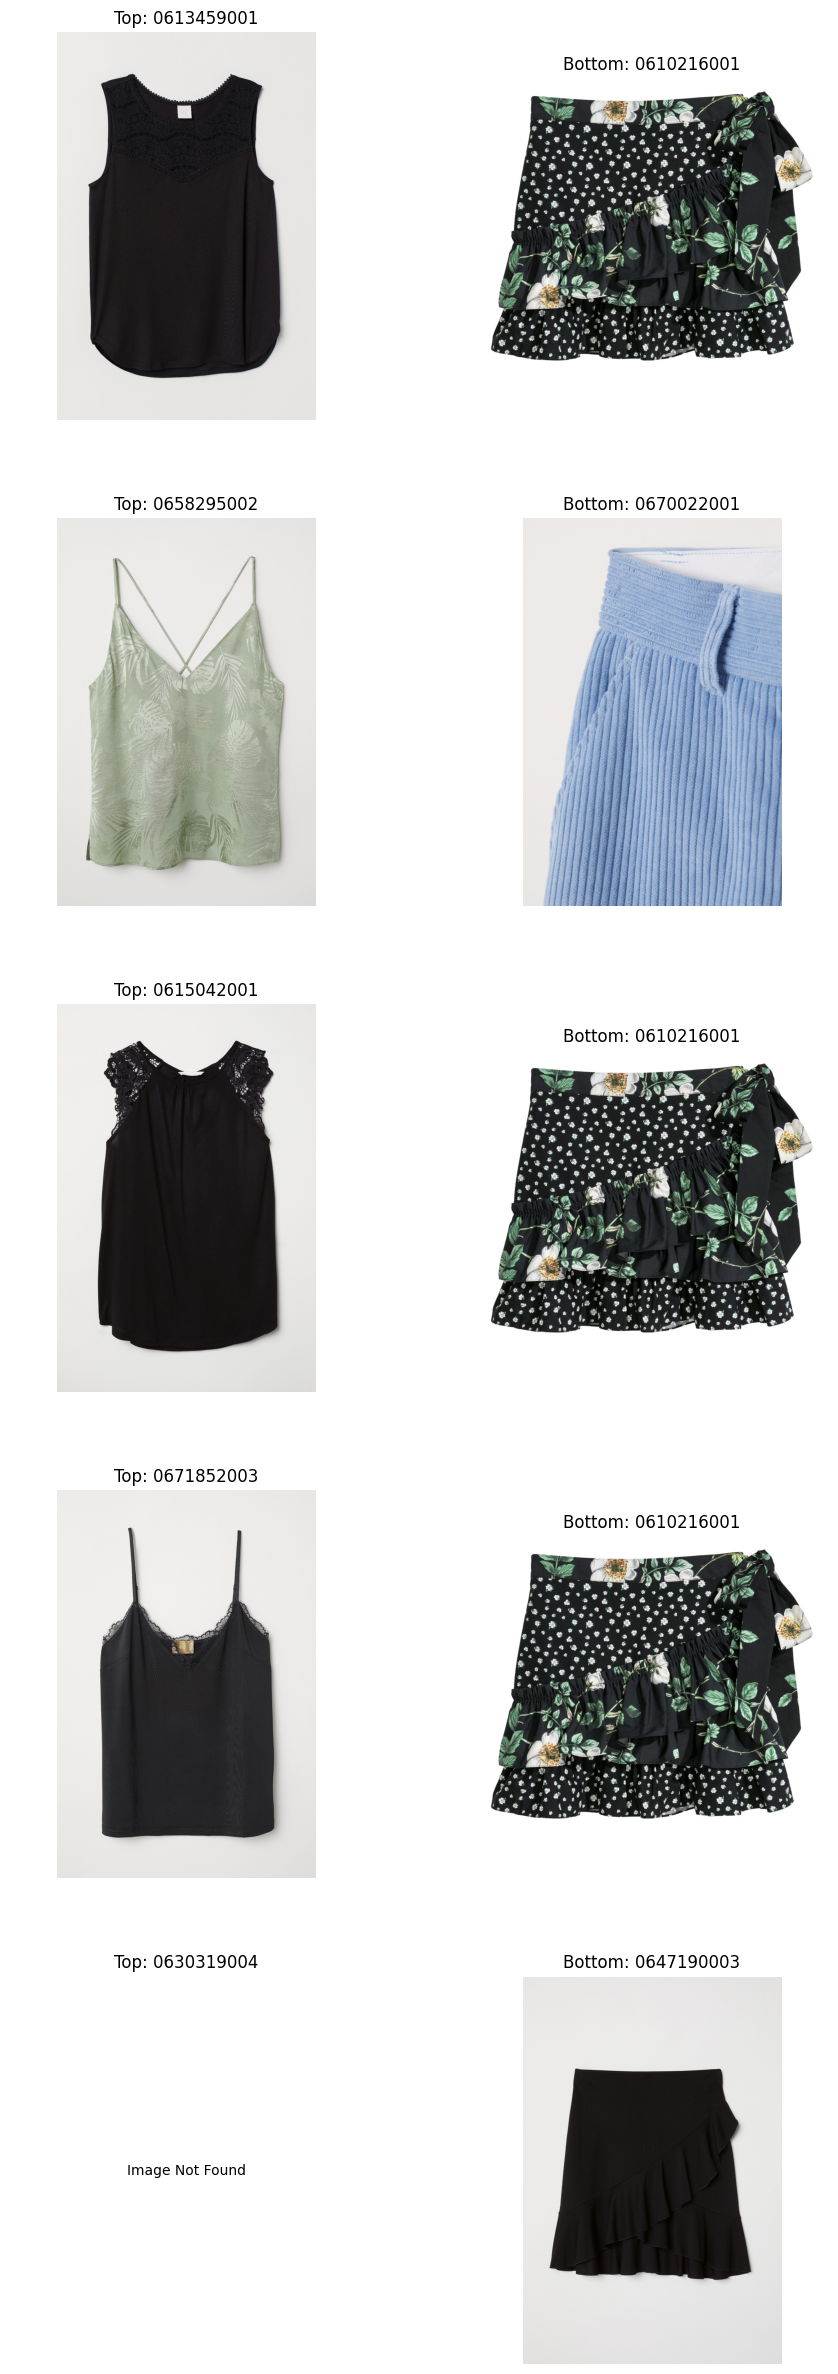

In [ ]:
print(f"Visualizing Top 5 Outfits..")
plot_outfits(relevant_matches, top_n=5)